In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("trends_analysed.csv")

df.head()

,post_id,title,category,score,num_comments,author,collected_at,engagement,is_popular
0,47618189,Tailscale's new macOS home,technology,380,193,tosh,2026-04-03T10:41:09.440248,0.506562,True
1,47617415,Good ideas do not need lots of lies in order t...,technology,203,87,sedev,2026-04-03T10:41:13.873076,0.426471,True
2,47621792,Post Mortem: axios NPM supply chain compromise,technology,56,30,Kyro38,2026-04-03T10:41:14.487956,0.526316,False
3,47617376,OpenAI Acquires TBPN,technology,177,148,surprisetalk,2026-04-03T10:41:21.275651,0.831461,True
4,47620933,Memo: A language that remembers only the last ...,technology,35,13,notem,2026-04-03T10:41:23.825438,0.361111,False


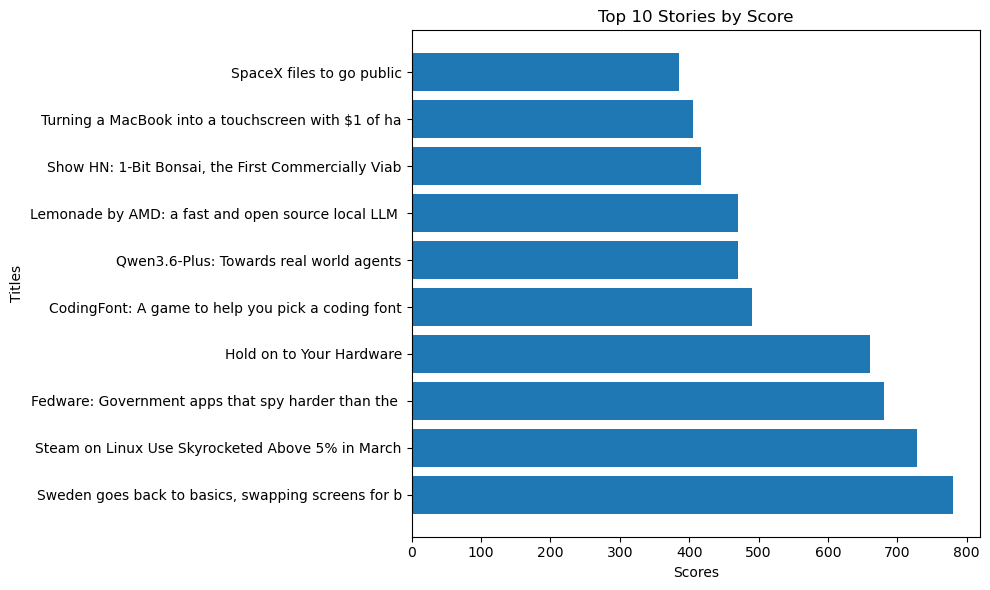

In [57]:
#sorted top 10 stories
top_10_stories = df.sort_values(by="score", ascending=False).head(10)

#shortened thelength of the title to 50 chars
short_title = top_10_stories['title'].str[:50]

plt.figure(figsize=(10,6))

plt.barh(short_title, top_10_stories['score'])
plt.title("Top 10 Stories by Score")
plt.xlabel("Scores")
plt.ylabel("Titles")
plt.tight_layout()
plt.savefig("outputs/chart1_top_stories.png")
plt.show()

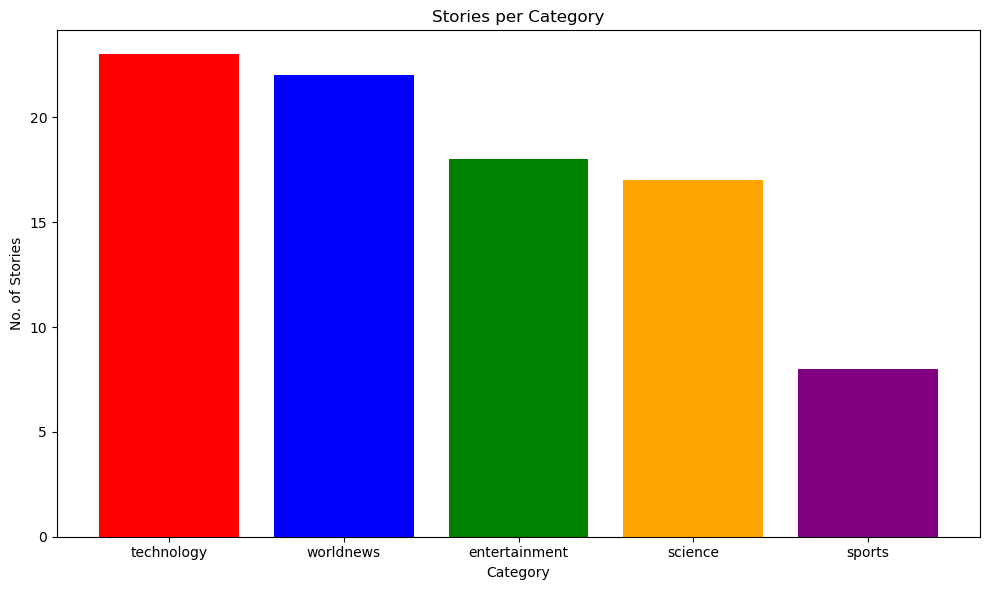

In [59]:
#Stories per Category 
stories_per_category = df['category'].value_counts()
#stories_per_category

plt.figure(figsize=(10, 6))

plt.bar(stories_per_category.index, stories_per_category.values, color=["red", "blue", "green", "orange", "purple"])
plt.title("Stories per Category")
plt.xlabel("Category")
plt.ylabel("No. of Stories")
plt.tight_layout()
plt.savefig("outputs/chart2_categories.png")
plt.show()


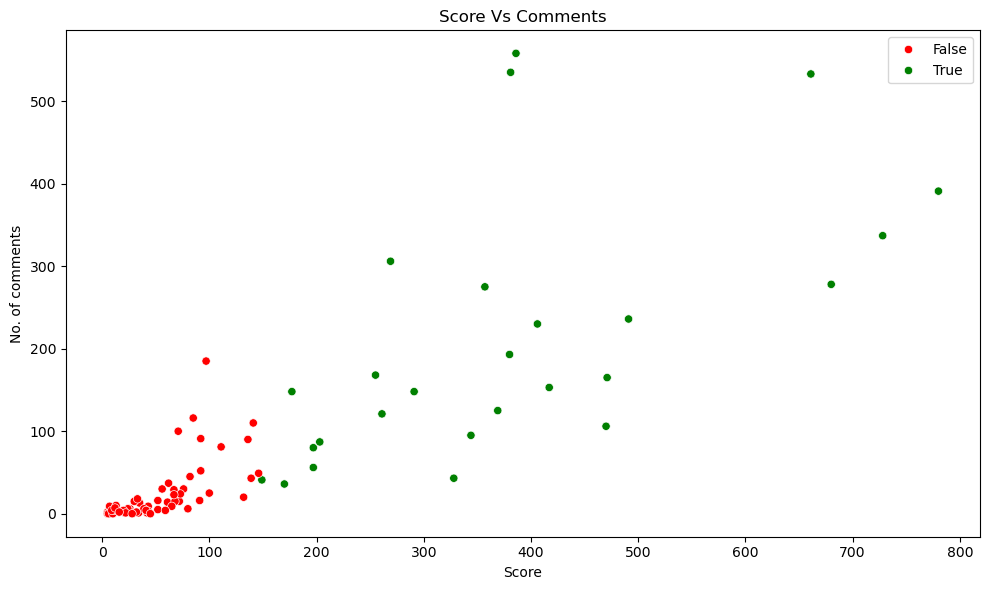

In [61]:
# Chart 3: Score vs Comments 
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='score', y='num_comments', hue='is_popular', palette={True: "green", False: "red"}) #used hue to highlight is_popular
plt.title("Score Vs Comments")
plt.xlabel("Score")
plt.ylabel("No. of comments")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/chart3_scatter.png")
plt.show()

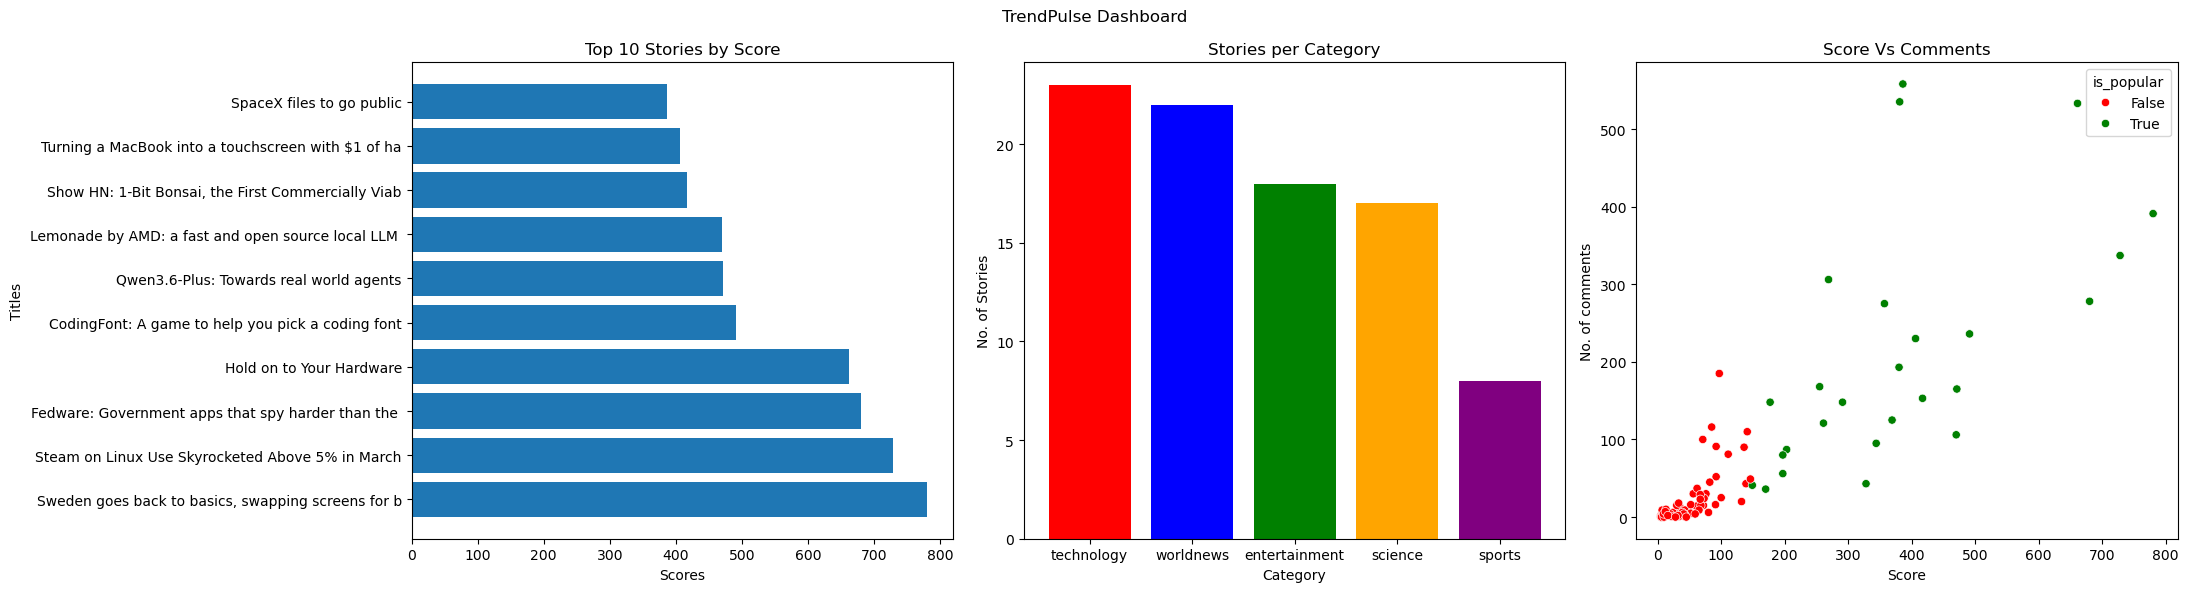

In [63]:
#Combine all 3 charts into one figure:
#Use plt.subplots(1, 3) or plt.subplots(2, 2) to lay them out together
#Add an overall title: "TrendPulse Dashboard"
#Save as outputs/dashboard.png
fig, axes = plt.subplots(1, 3, figsize=(22,6))

#Chart 1 - Top 10 Stories
top_10_stories = df.sort_values(by="score", ascending=False).head(10)

#shortened thelength of the title to 50 chars
short_title = top_10_stories['title'].str[:50]

axes[0].barh(short_title, top_10_stories['score'])
axes[0].set_title("Top 10 Stories by Score")
axes[0].set_xlabel("Scores")
axes[0].set_ylabel("Titles")

#Chart 2 - Stories per Category
stories_per_category = df['category'].value_counts()

axes[1].bar(stories_per_category.index, stories_per_category.values, color=["red", "blue", "green", "orange", "purple"])
axes[1].set_title("Stories per Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("No. of Stories")

#Chart 3 - Score vs Comments 
import seaborn as sns

sns.scatterplot(data=df, x='score', y='num_comments', hue='is_popular', palette={True: "green", False: "red"}, ax=axes[2])
axes[2].set_title("Score Vs Comments")
axes[2].set_xlabel("Score")
axes[2].set_ylabel("No. of comments")

plt.suptitle("TrendPulse Dashboard")

plt.tight_layout()
plt.savefig("outputs/Dashboard.png")
plt.show()
